# **TinyML: Despliega tus modelos de Machine Learning en un ESP32**


Antes de profundizar en la técnica, es útil entender por qué existe **TinyML**. 

Cuando el equipo de "OK Google" comenzó a trabajar en el reconocimiento de voz para Android, se enfrentaron a un reto enorme: el sistema debía estar siempre encendido, escuchando la frase de activación, pero sin agotar la batería del teléfono. 

Para lograrlo, desarrollaron redes neuronales de apenas **14 kilobytes (KB)**. Estos modelos eran tan pequeños porque no se ejecutaban en el procesador principal (CPU), el cual consume mucha energía y suele estar apagado mientras el teléfono está en el bolsillo. En su lugar, corrían en chips especializados llamados Procesadores de Señales Digitales (DSPs). 



Estos DSPs solo cuentan con unas pocas decenas de kilobytes de memoria RAM y Flash, pero tienen una ventaja crítica: consumen apenas unos pocos **milliwatts (mW)** de potencia. Este es el corazón de TinyML: la capacidad de llevar inteligencia a dispositivos con recursos extremadamente limitados para que puedan interactuar con el mundo real de forma autónoma y eficiente.

---

## **¿Qué es Machine Learning (ML)?**

Imagina una máquina industrial que opera bajo una carga pesada; si llegara a averiarse, la reparación resultaría sumamente costosa. Sin embargo, si recolectamos datos de la máquina mientras funciona (como vibración, temperatura o consumo eléctrico), podríamos predecir en qué momento es probable que ocurra un fallo.

El **Machine Learning (ML)** es una técnica que permite predecir el estado de un sistema basándose en observaciones pasadas. En lugar de programar reglas manuales de forma explícita, utilizamos los datos obtenidos para que el sistema aprenda patrones y pueda predecir estados futuros.



### El proceso: Entrenamiento e Inferencia

Los algoritmos de ML construyen **modelos** del sistema a partir de los datos que se le proporcionan mediante un proceso denominado **entrenamiento**. Una vez que el modelo ha aprendido, se comporta de forma similar a un programa de computadora: le entregamos nuevos datos y este genera predicciones. A este acto de ejecutar el modelo para obtener un resultado se le conoce como **inferencia**.

### Deep Learning

Uno de los enfoques más populares dentro del ML es el **Deep Learning** (Aprendizaje Profundo), el cual se inspira en una idea simplificada de cómo funciona el cerebro humano. En este método, una red de neuronas artificiales (representadas matemáticamente mediante arreglos o tensores) es entrenada para encontrar relaciones complejas entre las entradas (*inputs*) y las salidas (*outputs*).

--- 


## Deep Learning Workflow (Flujo de trabajo)

Para desarrollar un proyecto de Deep Learning, generalmente seguimos estos pasos:

1. **Definir la meta:** Establecer qué queremos predecir.
2. **Recolectar un dataset:** Obtener los datos necesarios para el aprendizaje.
3. **Diseñar la arquitectura:** Elegir la estructura de la red neuronal.
4. **Entrenar el modelo:** Ajustar los parámetros del modelo con los datos.
5. **Convertir el modelo:** Optimizarlo para dispositivos de bajos recursos (crucial en TinyML).
6. **Ejecutar la inferencia:** Poner a prueba el modelo con nuevos datos.
7. **Evaluar y solucionar problemas:** Analizar el desempeño y realizar ajustes.

---

### 1. Definir una meta

Al diseñar cualquier algoritmo, es fundamental establecer exactamente qué se desea lograr. En Machine Learning, esto implica decidir qué quieres predecir, qué datos necesitas adquirir y qué arquitectura de modelo es la más adecuada para el problema.

Por ejemplo, si queremos detectar una falla en una máquina, podemos definir dos clases de comportamiento: **Normal** (funcionamiento correcto) y **Anómalo** (indicativo de una posible avería).



### 2. Adquirir un dataset

Una vez definida la meta, empezamos a identificar y recolectar los datos. Para que el modelo sea efectivo, debemos considerar tres pilares:

* **Selección de datos:** Es vital entrenar los modelos utilizando información que sea realmente relevante para el problema. Datos irrelevantes solo introducirán ruido y disminuirán la precisión.
* **Recolección de datos:** Determinar la cantidad exacta de datos necesarios es complejo, ya que depende de la relación entre las variables, el ruido presente y qué tan diferentes sean las clases entre sí. Sin embargo, existe una regla general en Deep Learning: **¡Cuantos más datos, mejor!**
* **Etiquetado de datos (Labeling):** Este es el proceso de asociar cada dato con su categoría correspondiente (por ejemplo, asignar la etiqueta "Anómalo" a una muestra de vibración excesiva). Sin etiquetas correctas, el modelo no podrá aprender a distinguir las clases durante el entrenamiento.


### 3. Diseñar la arquitectura del modelo

Al entrenar un modelo, puedes optar por diseñar tu propia arquitectura o basarte en estructuras existentes desarrolladas por investigadores. En el mundo del Deep Learning, se publican arquitecturas nuevas prácticamente a diario.

Sin embargo, en **TinyML** debes tener muy en cuenta las limitaciones de hardware. Debido a que los microcontroladores generalmente poseen memoria limitada (SRAM y Flash) y procesadores con menor velocidad de reloj, los modelos grandes requieren más recursos y tardan más tiempo en ejecutarse. El tamaño del modelo depende directamente del número de neuronas que contiene y de la forma en que estas neuronas están interconectadas.

Para optimizar este proceso, se utilizan las siguientes técnicas:

* **Generación de características (Feature Engineering):** En ML, el término *features* se refiere a tipos específicos de información derivada de los datos brutos con los que se entrena el modelo. No todos los modelos procesan los datos de la misma forma; seleccionar las características adecuadas es vital para reducir la carga computacional.

* **Ventaneo (Windowing):** Esta técnica consiste en agrupar datos de series temporales en "ventanas" de tiempo específicas. Se promedian o procesan los valores dentro de esa ventana para generar características que luego se etiquetan (por ejemplo, como "normal" o "anómalo"). Esto permite que el modelo analice comportamientos en el tiempo en lugar de puntos de datos aislados.

* **Normalización (Normalization):** Consiste en ajustar los valores de entrada para que estén en rangos similares (por ejemplo, entre 0 y 1 o entre -1 y 1). Esto facilita y acelera el proceso de entrenamiento, evitando que variables con magnitudes grandes dominen sobre las pequeñas.

El proceso de Machine Learning es **iterativo**: se define el objetivo, se recolectan datos, se extraen características, se elige el modelo y se ajusta continuamente (ajuste de hiperparámetros) hasta obtener los resultados deseados.

### 4. Entrenar el modelo

El entrenamiento es el proceso mediante el cual nuestro modelo aprende a producir una salida correcta para un conjunto determinado de entradas. Esto implica alimentar el modelo con los datos de entrenamiento y realizar pequeños ajustes iterativos hasta que las predicciones sean lo más precisas posibles.

#### Anatomía de un modelo
Un modelo es una red neuronal simulada, representada matemáticamente por arreglos de números organizados en capas. Estos números se conocen como **pesos** (*weights*) y **sesgos** (*biases*), que colectivamente forman los **parámetros** de la red.

* **Batches (Lotes):** Son pequeños grupos de datos que se procesan en cada paso del entrenamiento para actualizar los parámetros.
* **Epochs (Épocas):** Es el número de veces que el modelo recorre el conjunto de datos completo durante el entrenamiento.

El entrenamiento se detiene cuando el modelo **converge**, es decir, cuando su rendimiento deja de mejorar significativamente.

#### Métricas de evaluación
Para saber qué tan bien va el proceso, utilizamos dos métricas principales:
1.  **Pérdida (*Loss*):** Indica qué tan lejos está la predicción del modelo del valor real. El objetivo es minimizarla.
2.  **Precisión (*Accuracy*):** Es el porcentaje de aciertos o predicciones correctas sobre el total de datos.



#### Underfitting y Overfitting

Un modelo "ajustado" (*fit*) es aquel que ha logrado converger y generalizar los patrones de los datos. Sin embargo, existen dos problemas comunes que impiden esto:

* **Underfitting (Subajuste):** Ocurre cuando el modelo es demasiado simple o no ha entrenado lo suficiente para captar la estructura de los datos. No rinde bien ni con los datos de entrenamiento ni con los nuevos.
* **Overfitting (Sobreajuste):** Ocurre cuando el modelo "memoriza" los datos de entrenamiento en lugar de aprender los patrones generales. Predice perfectamente los datos conocidos, pero falla al enfrentarse a datos nuevos.

> **Ejemplo:** Si entrenamos un modelo para clasificar perros y gatos, pero en todas las fotos los perros están al aire libre y los gatos en interiores, el modelo podría aprender erróneamente que "presencia de cielo = perro". Si luego le mostramos un perro dentro de una habitación, no sabrá clasificarlo.


<img src="https://i.imgur.com/q3ex30Z.jpeg" width="75%">

Para combatir el **overfitting** podemos:
* Reducir la complejidad del modelo (menos neuronas o capas).
* Aplicar técnicas de **regularización**.
* Usar **Data Augmentation** (generar datos artificiales variando los existentes, como rotar o recortar imágenes).
* La mejor solución siempre será utilizar un dataset más grande y variado.



#### Training, Validation y Testing

Para asegurar que el modelo realmente funcione, dividimos nuestros datos en tres grupos:

1.  **Training set (Entrenamiento):** El conjunto de datos con el que el modelo aprende y ajusta sus parámetros.
2.  **Validation set (Validación):** Datos que el modelo no usa para ajustar pesos, pero que consultamos *durante* el entrenamiento para detectar si hay overfitting.
3.  **Testing set (Prueba):** Se utiliza solo al final, una vez que el entrenamiento ha terminado, para medir el rendimiento real con datos que el modelo jamás ha visto.



Una vez que el modelo alcanza un desempeño aceptable, la fase de entrenamiento finaliza. **¡Es hora de preparar nuestro modelo para que se ejecute en un dispositivo físico!**


### 5. Convertir el modelo

Una vez entrenado, el modelo suele ser demasiado grande para un microcontrolador. Para solucionar esto, utilizamos **TensorFlow Lite Converter**, que transforma el modelo original en un formato optimizado (`.tflite`). 

Durante este paso, aplicamos técnicas de **Optimización de Modelos**:
* **Cuantización:** Reduce la precisión de los números (por ejemplo, de *float32* a *int8*). Esto disminuye drásticamente el uso de memoria y acelera la ejecución sin perder demasiada precisión.
* **Compresión:** Elimina conexiones innecesarias para que el archivo final sea lo más ligero posible.



### 6. Ejecutar la inferencia

Con el modelo ya convertido y cargado en nuestro dispositivo (como un Arduino Nano 33 BLE o una ESP32), el sistema está listo para trabajar. 

El modelo recibe datos en tiempo real de los sensores, realiza el procesamiento matemático y genera una **predicción**. En TinyML, es común aplicar un "post-procesamiento", como promediar varias predicciones consecutivas, para filtrar el ruido de los sensores y evitar falsos positivos momentáneos.

### 7. Evaluar y solucionar problemas

El trabajo no termina cuando el modelo corre en el dispositivo. La fase final consiste en evaluar el rendimiento en el **mundo real**, lo cual puede revelar problemas que no vimos en la computadora:

* **Factores ambientales:** Ruido, temperatura o vibraciones inesperadas que afectan los sensores.
* **Fallas de Hardware:** Consumo excesivo de batería o latencia (lentitud) en la respuesta.
* **Concept Drift:** Cuando los datos del mundo real cambian con el tiempo y el modelo deja de ser preciso.

Si el rendimiento no es el esperado, el proceso vuelve a empezar: recolectamos más datos de estos fallos, reentrenamos el modelo y lo volvemos a implementar. ¡El aprendizaje automático es un ciclo de mejora continua!

---




# **¡Manos a la obra!**

Ahora que tenemos una base sólida sobre qué es el **Machine Learning** y los retos que implica optimizar modelos para hardware limitado, es momento de pasar de la teoría a la práctica.

En este notebook, entrenaremos un modelo optimizado capaz de modelar patrones en datos generados por una función **seno**. El objetivo es que la red neuronal aprenda a recibir un valor de entrada $x$ y predecir su correspondiente valor de salida $y$ (su seno), emulando el comportamiento de una señal periódica.



Este es el ejercicio fundamental para entender cómo funciona **TensorFlow Lite for Microcontrollers**. Al finalizar, tendremos un modelo lo suficientemente pequeño como para vivir y tomar decisiones dentro de un **ESP32**.

**¡Es tiempo de empezar a construir nuestro primer modelo!**

In [1]:
# Carpeta donde se guardaran los modelos
import os
MODELS_DIR = 'models/'
if not os.path.exists(MODELS_DIR):
    os.mkdir(MODELS_DIR)
MODEL_TF = MODELS_DIR + 'model'
MODEL_NO_QUANT_TFLITE = MODELS_DIR + 'model_no_quant.tflite'
MODEL_TFLITE = MODELS_DIR + 'model.tflite'
MODEL_TFLITE_MICRO = MODELS_DIR + 'model.cc'

In [2]:
#Run this if you want to force to use CPU
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"   # see issue #152
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [ ]:
# TensorFlow es una biblioteca de código abierto para machine learning
import tensorflow as tf

# Keras es la API de alto nivel de TensorFlow para deep learning
from tensorflow import keras
# Numpy es una biblioteca para cálculo numérico y manejo de arreglos
import numpy as np
# Pandas es una biblioteca para la manipulación y análisis de datos
import pandas as pd
# Matplotlib es una biblioteca para la generación de gráficos
import matplotlib.pyplot as plt
# Math es la biblioteca matemática estándar de Python
import math

# Configuración de una semilla para asegurar la reproducibilidad de los experimentos
seed = 1
np.random.seed(seed)
tf.random.set_seed(seed)

I0000 00:00:1774380798.204331   13043 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774380799.609218   13043 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774380804.173569   13043 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Dataset

### 1. Generación de datos

En la siguiente celda, generaremos un conjunto de datos con valores aleatorios para la variable `x`. A partir de estos, calcularemos sus correspondientes valores de seno (`y`) y los visualizaremos en una gráfica para observar la distribución de los puntos que usaremos para el entrenamiento.

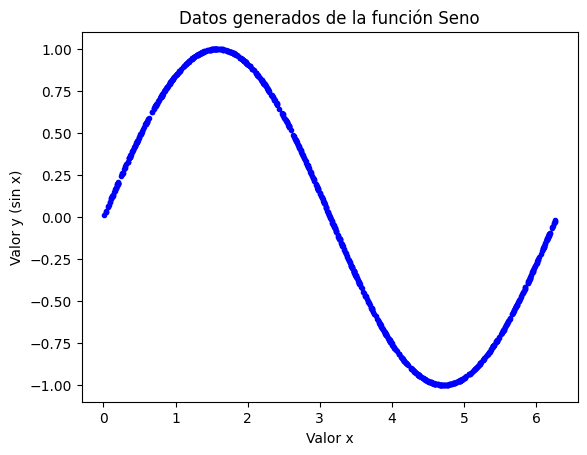

In [7]:
# Cantidad total de puntos de datos (muestras)
SAMPLES = 1000

# Generamos un conjunto de números aleatorios distribuidos uniformemente 
# en el rango de 0 a 2π, lo que cubre una oscilación completa de la onda senoidal
x_values = np.random.uniform(
    low=0, high=2*math.pi, size=SAMPLES).astype(np.float32)

# Mezclamos los valores para garantizar que no estén en un orden específico
np.random.shuffle(x_values)

# Calculamos los valores de seno correspondientes
y_values = np.sin(x_values).astype(np.float32)

# Graficamos los datos. El argumento 'b.' le indica a la librería que use puntos azules.
plt.plot(x_values, y_values, 'b.')
plt.title("Datos generados de la función Seno")
plt.xlabel("Valor x")
plt.ylabel("Valor y (sin x)")
plt.show()

### 2. Añadir Ruido

Dado que los datos fueron generados directamente por la función seno, estos se ajustan a una curva perfecta y suave. 

Sin embargo, los modelos de **Machine Learning** son especialmente útiles para extraer patrones de datos reales que suelen ser "sucios" o ruidosos. Para demostrar esto, añadiremos algo de ruido aleatorio a nuestros datos para aproximarlos a una señal más cercana a la realidad (como la que obtendrías de un sensor físico).

En la siguiente celda, añadiremos un pequeño valor aleatorio a cada punto y visualizaremos la nueva gráfica:

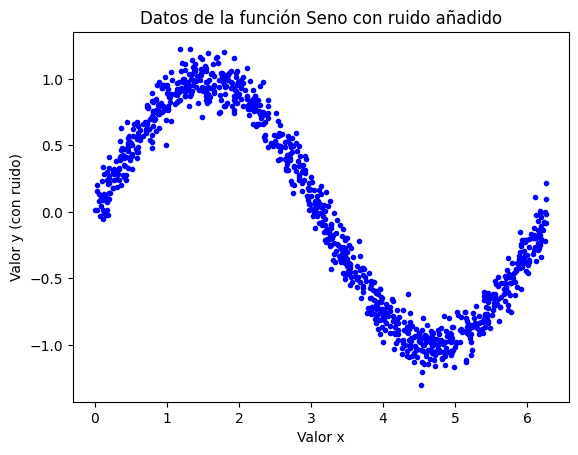

In [8]:
# Añadimos un pequeño número aleatorio a cada valor de 'y'
# Esto simula el ruido o las pequeñas variaciones de un entorno real
y_values += 0.1 * np.random.randn(*y_values.shape)

# Graficamos los datos resultantes
plt.plot(x_values, y_values, 'b.')
plt.title("Datos de la función Seno con ruido añadido")
plt.xlabel("Valor x")
plt.ylabel("Valor y (con ruido)")
plt.show()

### 3. División de los Datos (Data Splitting)

Ahora tenemos un conjunto de datos con ruido que se aproxima a la realidad. Utilizaremos estos puntos para entrenar nuestro modelo.

Para evaluar la precisión del modelo, necesitamos comparar sus predicciones con datos reales y verificar qué tan bien se ajustan. Esta evaluación ocurre en dos momentos: **durante** el entrenamiento (fase de validación) y **después** del entrenamiento (fase de prueba o testing). En ambos casos, es fundamental utilizar datos nuevos que el modelo no haya visto anteriormente durante el ajuste de sus parámetros.

Dividiremos los datos de la siguiente manera:
1.  **Entrenamiento (Training):** 60%
2.  **Validación (Validation):** 20%
3.  **Prueba (Testing):** 20%



El siguiente código dividirá nuestros datos y graficará cada conjunto con un color diferente para visualizarlos:

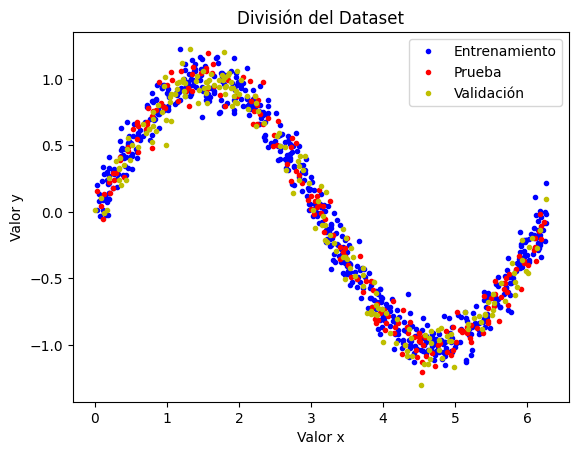

In [9]:
# Usaremos el 60% de los datos para entrenamiento y el 20% para pruebas.
# El 20% restante se usará para validación. Calculamos los índices de corte.
TRAIN_SPLIT = int(0.6 * SAMPLES)
TEST_SPLIT = int(0.2 * SAMPLES + TRAIN_SPLIT)

# Usamos np.split para dividir nuestros datos en tres partes.
# El segundo argumento de np.split es un arreglo de índices donde se cortarán los datos.
# Al proporcionar dos índices, los datos se dividen en tres secciones.
x_train, x_test, x_validate = np.split(x_values, [TRAIN_SPLIT, TEST_SPLIT])
y_train, y_test, y_validate = np.split(y_values, [TRAIN_SPLIT, TEST_SPLIT])

# Verificamos que la suma de las divisiones coincida con el total de muestras iniciales
assert (x_train.size + x_validate.size + x_test.size) == SAMPLES

# Graficamos cada partición con un color diferente para diferenciarlas:
plt.plot(x_train, y_train, 'b.', label="Entrenamiento")
plt.plot(x_test, y_test, 'r.', label="Prueba")
plt.plot(x_validate, y_validate, 'y.', label="Validación")
plt.title("División del Dataset")
plt.xlabel("Valor x")
plt.ylabel("Valor y")
plt.legend()
plt.show()

## Diseño del Modelo

### 1. Diseñar la Arquitectura

Vamos a construir un modelo de red neuronal simple que tomará un valor de entrada (`x`) y lo utilizará para predecir un valor de salida numérico (el seno de `x`). Este tipo de problema se conoce como **regresión**. El modelo utilizará capas de neuronas para intentar aprender los patrones subyacentes en los datos de entrenamiento y así realizar predicciones.

Para empezar, definiremos una estructura de dos capas:

* **Primera capa:** Recibe una única entrada (nuestro valor `x`) y la procesa a través de **8 neuronas**. Cada neurona se "activará" en cierto grado dependiendo de su estado interno (sus valores de **peso** y **sesgo**).
* **Segunda capa (Salida):** Recibe las activaciones de la primera capa. Esta capa consiste en una sola neurona que aplica sus propios pesos y sesgo para calcular el valor final de salida, que será nuestra predicción de `y`.



> **Nota:** El código siguiente utiliza **Keras**, la API de alto nivel de TensorFlow. Una vez definida la red, la "compilamos" especificando los parámetros que determinarán cómo aprenderá durante el entrenamiento.

In [10]:
# Usaremos Keras para crear una arquitectura de modelo secuencial simple
model_1 = tf.keras.Sequential()

# La primera capa recibe una entrada escalar y la pasa por 8 "neuronas".
# Las neuronas deciden su activación basándose en la función de activación 'relu'.
model_1.add(keras.layers.Dense(8, activation='relu', input_shape=(1,)))

# La capa final es una sola neurona, ya que queremos predecir un único valor de salida
model_1.add(keras.layers.Dense(1))

# Compilamos el modelo usando el optimizador estándar 'adam' y la función de pérdida 
# de error cuadrático medio (MSE), ideal para problemas de regresión.
# También monitoreamos el error absoluto medio (MAE).
model_1.compile(optimizer='adam', loss='mse', metrics=['mae'])

/home/pinpa/Documents/programacion/tinyml_hello/tinyhello/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1774381627.070797   13043 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
I0000 00:00:1774381627.071078   13043 cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DEVICES="-1"
I0000 00:00:1774381627.071330   13043 cuda_diagnostics.cc:163] CUDA_VISIBLE_DEVICES is set to -1 - this hides all GPUs from CUDA
I0000 00:00:1774381627.071349   13043 cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module


In [12]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77 (312.00 B)

 Trainable params: 25 (100.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 52 (212.00 B)

### 2. Entrenar el Modelo

Con el modelo definido y los datos preparados, procederemos al entrenamiento. En este paso, la red ajustará sus **pesos** y **sesgos** de manera iterativa a través de los lotes y épocas que definimos.

Como vimos anteriormente, utilizaremos los datos de validación para monitorear el progreso y asegurar que el modelo esté convergiendo correctamente.

In [11]:
# Iniciamos el entrenamiento del modelo
# Configuramos 500 épocas y un tamaño de lote (batch size) de 64
history_1 = model_1.fit(x_train, y_train, epochs=500, batch_size=64,
                        validation_data=(x_validate, y_validate))

Epoch 1/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 1.3834 - mae: 1.0818 - val_loss: 1.2863 - val_mae: 1.0433
Epoch 2/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.2542 - mae: 1.0227 - val_loss: 1.1768 - val_mae: 0.9891
Epoch 3/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.1392 - mae: 0.9666 - val_loss: 1.0798 - val_mae: 0.9381
Epoch 4/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.0380 - mae: 0.9141 - val_loss: 0.9946 - val_mae: 0.8906
Epoch 5/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.9494 - mae: 0.8650 - val_loss: 0.9201 - val_mae: 0.8467
Epoch 6/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.8720 - mae: 0.8193 - val_loss: 0.8549 - val_mae: 0.8060
Epoch 7/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.8044 - mae: 0.7768 - val_loss: 0.7977 - val_mae: 0.7684
Epoch 8/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7451 - mae: 0.7375 - val_loss: 0.7474 - val_mae: 0.7357
Epoch 9/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss:

### 3. Visualización de Métricas

#### 1. Pérdida (Loss / Error Cuadrático Medio)

Como vimos en la teoría, durante el entrenamiento medimos el rendimiento del modelo tanto con los datos de entrenamiento como con los de validación. Esta métrica nos indica qué tan lejos están las predicciones de los valores reales.



Las siguientes celdas mostrarán esta evolución de forma gráfica para verificar si el modelo está convergiendo correctamente:

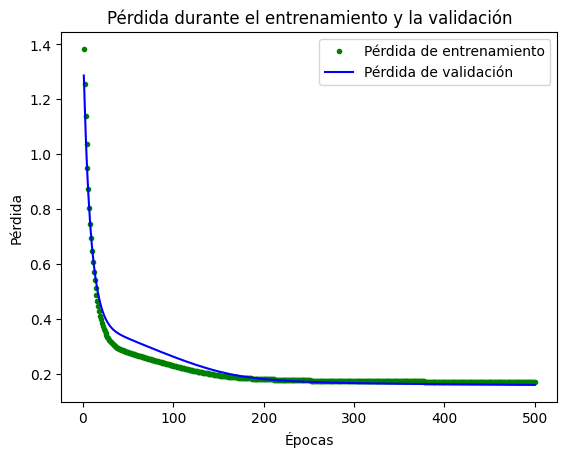

In [14]:
# Extraemos los valores de pérdida del historial de entrenamiento
train_loss = history_1.history['loss']
val_loss = history_1.history['val_loss']

# Creamos un rango de épocas para el eje X
epochs = range(1, len(train_loss) + 1)

# Graficamos la pérdida de entrenamiento y validación
plt.plot(epochs, train_loss, 'g.', label='Pérdida de entrenamiento')
plt.plot(epochs, val_loss, 'b', label='Pérdida de validación')
plt.title('Pérdida durante el entrenamiento y la validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

La gráfica muestra la **pérdida** (*loss*), es decir, la diferencia entre las predicciones del modelo y los datos reales para cada época. Como definimos anteriormente, el método utilizado es el **error cuadrático medio (MSE)**.

Podemos observar que la pérdida disminuye rápidamente durante las primeras 25 épocas antes de estabilizarse. Esto indica que el modelo está mejorando y generando predicciones cada vez más precisas.

Nuestro objetivo es detener el entrenamiento cuando el modelo deje de mejorar o cuando la **pérdida de entrenamiento** sea significativamente menor que la **pérdida de validación**, lo que indicaría que el modelo ha memorizado los datos (overfitting) y ya no puede generalizar ante datos nuevos.

Para que la parte más estable de la gráfica sea más legible, omitiremos las primeras 50 épocas:

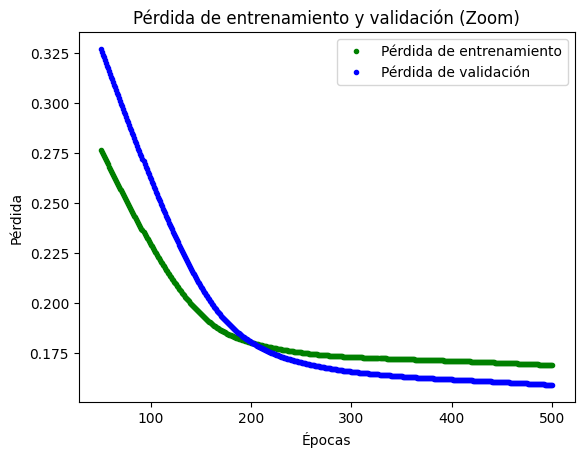

In [15]:
# Excluimos las primeras épocas para que la gráfica sea más fácil de leer
SKIP = 50

plt.plot(epochs[SKIP:], train_loss[SKIP:], 'g.', label='Pérdida de entrenamiento')
plt.plot(epochs[SKIP:], val_loss[SKIP:], 'b.', label='Pérdida de validación')
plt.title('Pérdida de entrenamiento y validación (Zoom)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

A partir de la gráfica, podemos observar que la pérdida continúa disminuyendo hasta aproximadamente las **200 épocas**, punto en el cual se vuelve mayormente estable. Esto nos indica que no es estrictamente necesario entrenar nuestra red más allá de ese límite para esta arquitectura específica.

Sin embargo, también notamos que el valor más bajo de la pérdida se mantiene alrededor de **0.155**. Esto significa que las predicciones de nuestra red tienen un error promedio cercano al **15%**. Además, los valores de la pérdida de validación presentan ciertas oscilaciones y, en ocasiones, son superiores a la pérdida de entrenamiento, lo que sugiere que el modelo aún tiene margen de mejora en su capacidad de generalización.

#### 2. Error Absoluto Medio (MAE)

Para obtener una visión más detallada del rendimiento de nuestro modelo, podemos graficar otra métrica: el **error absoluto medio** (MAE). A diferencia del MSE, el MAE nos da una idea más directa de qué tan lejos están las predicciones de los números reales en las mismas unidades que nuestra salida:

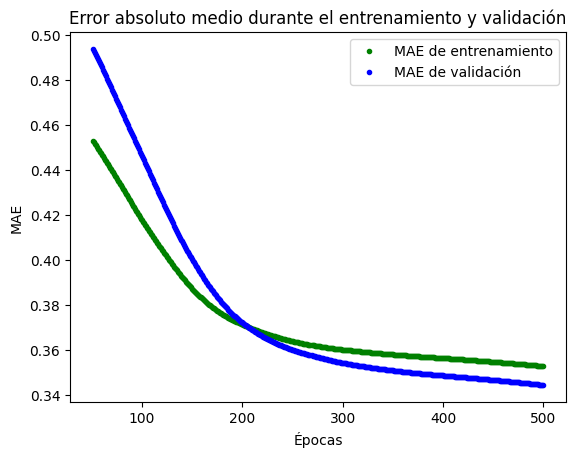

In [19]:
# Limpiamos la figura actual para evitar que se encimen gráficas anteriores
plt.clf()

# Graficamos el Error Absoluto Medio (MAE), que es otra forma de
# medir la magnitud del error en las predicciones.
train_mae = history_1.history['mae']
val_mae = history_1.history['val_mae']

# Graficamos el MAE de entrenamiento (puntos verdes) y de validación (puntos azules)
plt.plot(epochs[SKIP:], train_mae[SKIP:], 'g.', label='MAE de entrenamiento')
plt.plot(epochs[SKIP:], val_mae[SKIP:], 'b.', label='MAE de validación')

# Añadimos títulos y etiquetas a los ejes
plt.title('Error absoluto medio durante el entrenamiento y validación')
plt.xlabel('Épocas')
plt.ylabel('MAE')
plt.legend()
plt.show()

Esta gráfica del **Error Absoluto Medio (MAE)** nos cuenta una historia distinta. Podemos observar que el error en los datos de entrenamiento es consistentemente más bajo que en los datos de validación. Esto sugiere que la red podría estar sufriendo de **overfitting**, es decir, ha memorizado los datos de entrenamiento de forma tan rígida que no puede realizar predicciones efectivas sobre datos nuevos.

Además, los valores del MAE son bastante altos (alrededor de **0.34** en el mejor de los casos). Esto significa que algunas de las predicciones del modelo tienen un error de al menos el 34%, lo cual nos indica que todavía estamos muy lejos de modelar con precisión la función seno.


#### 3. Salidas Reales vs. Predichas

Para entender mejor qué está sucediendo "bajo el capó", compararemos las predicciones del modelo contra el conjunto de datos de **prueba** (*test dataset*) que reservamos al principio:

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1662 - mae: 0.3473 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


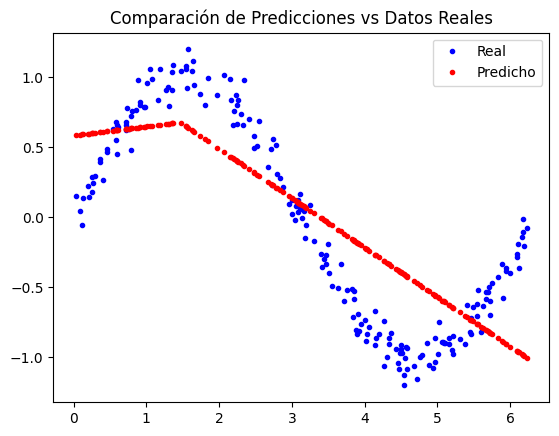

In [21]:
# Calculate and print the loss on our test dataset
test_loss, test_mae = model_1.evaluate(x_test, y_test)

# Usamos el modelo para predecir los valores a partir del conjunto de prueba
y_test_pred = model_1.predict(x_test)

# Graficamos las predicciones frente a los valores reales
plt.clf()
plt.title('Comparación de Predicciones vs Datos Reales')
plt.plot(x_test, y_test, 'b.', label='Real')
plt.plot(x_test, y_test_pred, 'r.', label='Predicho')
plt.legend()
plt.show()



#### ¿Por qué el modelo falló?

Al comparar las predicciones (rojo) con los datos reales (azul), es evidente que el modelo **no es suficiente**. En lugar de seguir la curva del seno, la red ha generado una aproximación lineal muy tosca que no alcanza los picos ni los valles de la señal.

Esto se debe a que el modelo sufre de **Underfitting** (subajuste): es demasiado simple y no tiene la capacidad matemática necesaria para representar la complejidad de una onda senoidal con solo 8 neuronas.



Para mejorar el resultado, necesitamos una arquitectura con mayor capacidad de aprendizaje.

## Diseño de un Modelo más Robusto

### 1. Diseño del Modelo

Dado que el primer modelo fue demasiado simple para captar la curvatura de la función seno, diseñaremos una nueva arquitectura con mayor **capacidad de aprendizaje**. 

Para este segundo modelo, incrementaremos el número de neuronas y añadiremos una capa oculta adicional. Esto permitirá que la red aprenda representaciones más complejas y se ajuste mejor a la naturaleza no lineal de nuestra señal.

In [24]:
# Creamos una arquitectura de modelo secuencial más robusta
model = tf.keras.Sequential()

# La primera capa ahora tiene 16 neuronas
model.add(keras.layers.Dense(16, activation='relu', input_shape=(1,)))

# Añadimos una segunda capa de 16 neuronas para aprender patrones más complejos
model.add(keras.layers.Dense(16, activation='relu'))

# La capa final sigue siendo una sola neurona para la salida escalar
model.add(keras.layers.Dense(1))

# Compilamos con el optimizador 'adam' y la función de pérdida 'mse'
model.compile(optimizer='adam', loss="mse", metrics=["mae"])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

### 2. Entrenamiento del modelo

Entrenaremos y guardaremos el nuevo modelo

In [25]:
# Entrenamiento del modelo
history = model.fit(x_train, y_train, epochs=500, batch_size=64,
                    validation_data=(x_validate, y_validate))



Epoch 1/500


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.4224 - mae: 0.5393 - val_loss: 0.4758 - val_mae: 0.6021
Epoch 2/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3904 - mae: 0.5381 - val_loss: 0.4535 - val_mae: 0.5880
Epoch 3/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3655 - mae: 0.5169 - val_loss: 0.4258 - val_mae: 0.5603
Epoch 4/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3443 - mae: 0.4998 - val_loss: 0.3996 - val_mae: 0.5453
Epoch 5/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3239 - mae: 0.4873 - val_loss: 0.3748 - val_mae: 0.5284
Epoch 6/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3051 - mae: 0.4731 - val_loss: 0.3505 - val_mae: 0.5095
Epoch 7/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2868 - mae: 0.4592 - val_loss: 0.3279 - val_mae: 0.4941
Epoch 8/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2701 - mae: 0.4470 - val_loss: 0.3062 - val_mae: 0.4775
Epoch 9/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2540 - m

In [ ]:
# Guardemos el modelo
model.export(MODEL_TF)

INFO:tensorflow:Assets written to: models/model/assets


INFO:tensorflow:Assets written to: models/model/assets


Saved artifact at 'models/model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor_18')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  128801322689616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128803298597904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128801322695376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128801322694992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128801322692880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128801322689808: TensorSpec(shape=(), dtype=tf.resource, name=None)


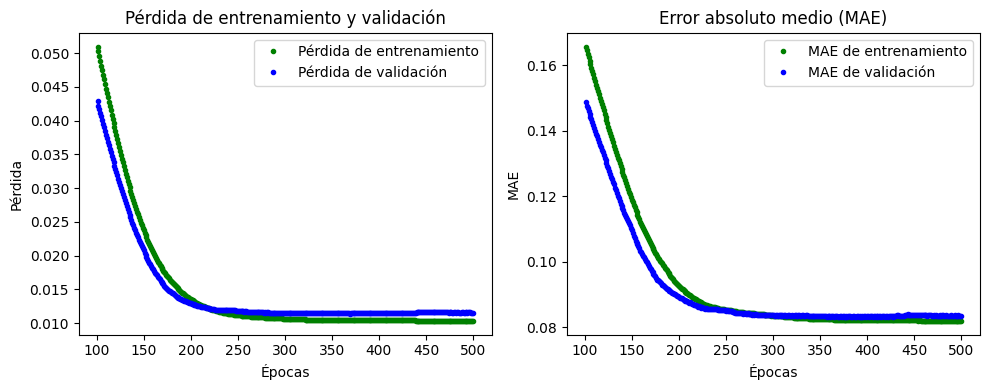

In [31]:
# Extraemos las métricas del historial de entrenamiento del segundo modelo
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_mae = history.history['mae']
val_mae = history.history['val_mae']

epochs = range(1, len(train_loss) + 1)

# Omitimos las primeras 100 épocas para observar mejor la fase de estabilidad
SKIP = 100

plt.figure(figsize=(10, 4))

# Gráfica de Pérdida (Loss)
plt.subplot(1, 2, 1)
plt.plot(epochs[SKIP:], train_loss[SKIP:], 'g.', label='Pérdida de entrenamiento')
plt.plot(epochs[SKIP:], val_loss[SKIP:], 'b.', label='Pérdida de validación')
plt.title('Pérdida de entrenamiento y validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

# Gráfica de Error Absoluto Medio (MAE)
plt.subplot(1, 2, 2)
plt.plot(epochs[SKIP:], train_mae[SKIP:], 'g.', label='MAE de entrenamiento')
plt.plot(epochs[SKIP:], val_mae[SKIP:], 'b.', label='MAE de validación')
plt.title('Error absoluto medio (MAE)')
plt.xlabel('Épocas')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

### 3. Grafica de metricas

Al observar las nuevas gráficas de entrenamiento, los resultados son drásticamente mejores:

* **Pérdida (Loss):** La pérdida ha caído de aproximadamente 0.15 en el primer modelo a cerca de **0.01**. Esto es una mejora de 15 veces en la precisión del ajuste.
* **Error Absoluto Medio (MAE):** El error ahora se sitúa alrededor de **0.08**, lo que significa que nuestras predicciones son mucho más precisas y están mucho más cerca de la curva real del seno.
* **Convergencia:** Ambas curvas (entrenamiento y validación) están muy juntas y se estabilizan cerca de las 300 épocas, lo que indica que el modelo ha aprendido el patrón general sin caer en un sobreajuste (*overfitting*) severo.


Este comportamiento nos confirma que añadir profundidad a la red le otorgó la capacidad necesaria para modelar la señal no lineal.

1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0085 - mae: 0.0739

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0093 - mae: 0.0768 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


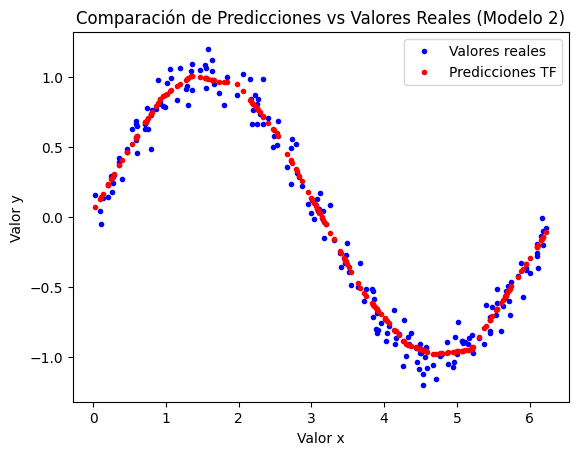

In [32]:
# Calculamos y mostramos la pérdida y el MAE sobre el conjunto de datos de prueba
test_loss, test_mae = model.evaluate(x_test, y_test)

# Realizamos las predicciones utilizando el conjunto de datos de prueba
y_test_pred = model.predict(x_test)

# Graficamos las predicciones frente a los valores reales para la validación visual
plt.clf()
plt.title('Comparación de Predicciones vs Valores Reales (Modelo 2)')
plt.plot(x_test, y_test, 'b.', label='Valores reales')
plt.plot(x_test, y_test_pred, 'r.', label='Predicciones TF')
plt.xlabel('Valor x')
plt.ylabel('Valor y')
plt.legend()
plt.show()

#### Validación Final: Comparación de Resultados

¡Mucho mejor! Las métricas de evaluación muestran que el segundo modelo tiene una pérdida y un MAE significativamente bajos en los datos de prueba. Visualmente, las predicciones ahora se alinean bastante bien con la forma de nuestra señal.

Es importante notar que el modelo no es perfecto; las predicciones no forman una curva de seno totalmente suave. Por ejemplo, se observa que la línea es casi recta cuando $x$ está entre 4.2 y 5.2. Podríamos intentar aumentar aún más la capacidad del modelo o aplicar técnicas avanzadas para evitar el sobreajuste (*overfitting*).

Sin embargo, una parte crucial del **Machine Learning** es *saber cuándo detenerse*. Este modelo es más que suficiente para nuestro caso de uso: hacer que unos LEDs parpadeen con un patrón agradable en nuestro microcontrolador.


## Conversión a TensorFlow Lite

### 1. Generar Modelos con y sin Cuantización

Ahora que tenemos un modelo con una precisión aceptable, utilizaremos el **TensorFlow Lite Converter** para transformarlo en un formato especial y eficiente en el uso de memoria, diseñado para dispositivos con recursos limitados.

Dado que este modelo se desplegará en un microcontrolador como el **ESP32**, ¡queremos que sea lo más pequeño posible! Una técnica fundamental para reducir el tamaño es la **cuantización**. 



La cuantización reduce la precisión de los pesos del modelo (y a veces de las activaciones) de números de punto flotante de 32 bits a enteros de 8 bits. Esto no solo ahorra una cantidad masiva de memoria, sino que también acelera la ejecución, ya que los cálculos con enteros son mucho más simples para el procesador del microcontrolador.

En la siguiente celda, realizaremos la conversión dos veces: una **sin cuantización** y otra **con cuantización**, para que podamos comparar sus tamaños más adelante.

In [46]:
# 1. Convertir el modelo al formato TensorFlow Lite sin cuantización
converter = tf.lite.TFLiteConverter.from_keras_model(model)
model_no_quant_tflite = converter.convert()

# Guardamos el modelo sin cuantizar en el disco
open(MODEL_NO_QUANT_TFLITE, "wb").write(model_no_quant_tflite)

# 2. Convertir el modelo al formato TensorFlow Lite con cuantización
# Definimos un dataset representativo para que el conversor sepa qué rangos de valores esperar
def representative_dataset():
  for i in range(500):
    # Proporcionamos datos de entrenamiento para calibrar la cuantización
    yield([x_train[i].reshape(1, 1)])

# Configuramos las optimizaciones por defecto (cuantización de pesos)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
# Forzamos la cuantización a enteros de 8 bits (INT8)
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
# Entregamos el dataset representativo para asegurar una cuantización precisa
converter.representative_dataset = representative_dataset

# Realizamos la conversión con optimización
model_tflite = converter.convert()

# Guardamos el modelo cuantizado en el disco
open(MODEL_TFLITE, "wb").write(model_tflite)

INFO:tensorflow:Assets written to: /tmp/tmpa7uz6ejx/assets


INFO:tensorflow:Assets written to: /tmp/tmpa7uz6ejx/assets


Saved artifact at '/tmp/tmpa7uz6ejx'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor_18')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  128801322689616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128803298597904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128801322695376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128801322694992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128801322692880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128801322689808: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1774384495.198309   13043 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1774384495.198325   13043 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1774384495.198578   13043 reader.cc:83] Reading SavedModel from: /tmp/tmpa7uz6ejx
I0000 00:00:1774384495.199471   13043 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1774384495.199481   13043 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpa7uz6ejx
I0000 00:00:1774384495.203726   13043 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1774384495.232445   13043 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpa7uz6ejx
I0000 00:00:1774384495.241018   13043 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 42450 microseconds.


INFO:tensorflow:Assets written to: /tmp/tmpw6br346b/assets


INFO:tensorflow:Assets written to: /tmp/tmpw6br346b/assets


Saved artifact at '/tmp/tmpw6br346b'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor_18')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  128801322689616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128803298597904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128801322695376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128801322694992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128801322692880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128801322689808: TensorSpec(shape=(), dtype=tf.resource, name=None)


/home/pinpa/Documents/programacion/tinyml_hello/tinyhello/lib/python3.12/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1774384495.592943   13043 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1774384495.592961   13043 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1774384495.593153   13043 reader.cc:83] Reading SavedModel from: /tmp/tmpw6br346b
I0000 00:00:1774384495.593627   13043 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1774384495.593637   13043 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpw6br346b
I0000 00:00:1774384495.597592   13043 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1774384495.626304   13043 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpw6br346b
I0000 00:00:1774384495.634038   13043 loader.cc

3880

### 2. Comparación del Rendimiento de los Modelos

Para demostrar que nuestros modelos siguen siendo precisos después de la conversión y la cuantización, compararemos sus predicciones y su pérdida utilizando el conjunto de datos de prueba.

#### Funciones Auxiliares

A diferencia de los modelos de TensorFlow estándar, los modelos de **TFLite** requieren un proceso manual para ejecutar datos a través de ellos. Definiremos las funciones `predict_tflite` (para obtener predicciones) y `evaluate_tflite` (para calcular la pérdida). 



*Nota: Estas funciones se encargan de escalar y desescalar los datos automáticamente si el modelo está cuantizado (pasando de float a int8 y viceversa).*

In [47]:
def predict_tflite(tflite_model, x_test):
  # Preparamos los datos de prueba
  x_test_ = x_test.copy()
  x_test_ = x_test_.reshape((x_test.size, 1))
  x_test_ = x_test_.astype(np.float32)

  # Inicializamos el intérprete de TFLite
  interpreter = tf.lite.Interpreter(model_content=tflite_model,
                                    experimental_op_resolver_type=tf.lite.experimental.OpResolverType.BUILTIN_REF)
  interpreter.allocate_tensors()

  input_details = interpreter.get_input_details()[0]
  output_details = interpreter.get_output_details()[0]

  # Si es necesario, cuantizamos la capa de entrada (de float a entero)
  input_scale, input_zero_point = input_details["quantization"]
  if (input_scale, input_zero_point) != (0.0, 0):
    x_test_ = x_test_ / input_scale + input_zero_point
    x_test_ = x_test_.astype(input_details["dtype"])
  
  # Invocamos el intérprete para cada dato
  y_pred = np.empty(x_test_.size, dtype=output_details["dtype"])
  for i in range(len(x_test_)):
    interpreter.set_tensor(input_details["index"], [x_test_[i]])
    interpreter.invoke()
    y_pred[i] = interpreter.get_tensor(output_details["index"]).flatten()[0]
  
  # Si es necesario, de-cuantizamos la capa de salida (de entero a float)
  output_scale, output_zero_point = output_details["quantization"]
  if (output_scale, output_zero_point) != (0.0, 0):
    y_pred = y_pred.astype(np.float32)
    y_pred = (y_pred - output_zero_point) * output_scale

  return y_pred

def evaluate_tflite(tflite_model, x_test, y_true):
  # Usamos la función de predicción definida arriba
  y_pred = predict_tflite(tflite_model, x_test)
  # Obtenemos la función de pérdida del modelo original (MSE)
  loss_function = tf.keras.losses.get(model_2.loss)
  loss = loss_function(y_true, y_pred).numpy()
  return loss

In [49]:
# Calcula las predicciones
y_test_pred_tf = model.predict(x_test)
y_test_pred_no_quant_tflite = predict_tflite(model_no_quant_tflite, x_test)
y_test_pred_tflite = predict_tflite(model_tflite, x_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


<Figure size 640x480 with 0 Axes>

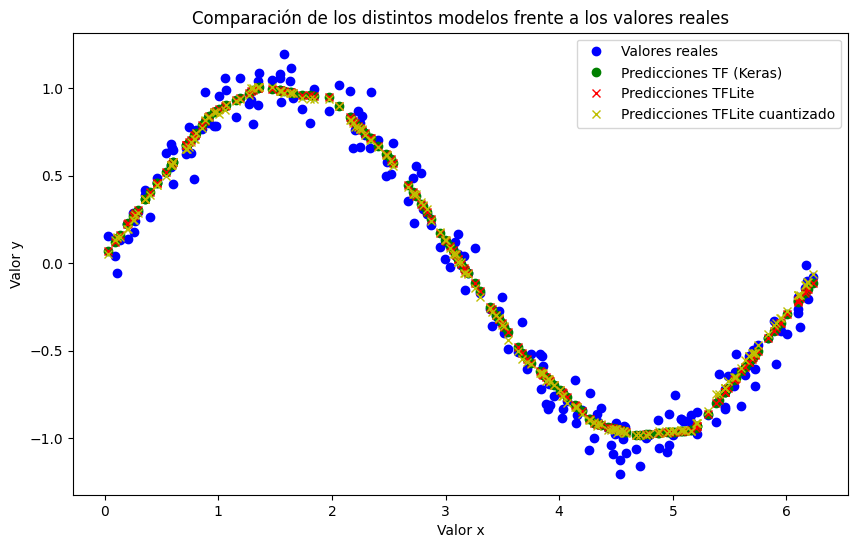

In [56]:
# Limpiamos la figura para la comparación final
plt.clf()
plt.figure(figsize=(10, 6))

# Título de la gráfica
plt.title('Comparación de los distintos modelos frente a los valores reales')

# Graficamos los valores reales del conjunto de prueba (puntos azules)
plt.plot(x_test, y_test, 'bo', label='Valores reales')

# Graficamos las predicciones del modelo original de TensorFlow (puntos rojos)
plt.plot(x_test, y_test_pred_tf, 'go', label='Predicciones TF (Keras)')

# Graficamos las predicciones del modelo TFLite sin cuantizar (X azules)
plt.plot(x_test, y_test_pred_no_quant_tflite, 'rx', label='Predicciones TFLite')

# Graficamos las predicciones del modelo TFLite cuantizado a INT8 (X verdes)
plt.plot(x_test, y_test_pred_tflite, 'yx', label='Predicciones TFLite cuantizado')

# Añadimos etiquetas y leyenda
plt.xlabel('Valor x')
plt.ylabel('Valor y')
plt.legend()
plt.show()

In [57]:
# Calcular la perdida
loss_tf, _ = model.evaluate(x_test, y_test, verbose=0)
loss_no_quant_tflite = evaluate_tflite(model_no_quant_tflite, x_test, y_test)
loss_tflite = evaluate_tflite(model_tflite, x_test, y_test)

In [58]:
# Comparar perdida
df = pd.DataFrame.from_records(
    [["TensorFlow", loss_tf],
     ["TensorFlow Lite", loss_no_quant_tflite],
     ["TensorFlow Lite Quantized", loss_tflite]],
     columns = ["Model", "Loss/MSE"], index="Model").round(4)
df

,Loss/MSE
Model,
TensorFlow,0.0093
TensorFlow Lite,0.0093
TensorFlow Lite Quantized,0.0096


In [ ]:
# Calcular tamaño
size_tf = os.path.getsize(MODEL_TF)
size_no_quant_tflite = os.path.getsize(MODEL_NO_QUANT_TFLITE)
size_tflite = os.path.getsize(MODEL_TFLITE)

In [60]:
# Comparar tamaño
pd.DataFrame.from_records(
    [["TensorFlow", f"{size_tf} bytes", ""],
     ["TensorFlow Lite", f"{size_no_quant_tflite} bytes ", f"(reduced by {size_tf - size_no_quant_tflite} bytes)"],
     ["TensorFlow Lite Quantized", f"{size_tflite} bytes", f"(reduced by {size_no_quant_tflite - size_tflite} bytes)"]],
     columns = ["Model", "Size", ""], index="Model")

,Size,
Model,,
TensorFlow,4096 bytes,
TensorFlow Lite,3296 bytes,(reduced by 800 bytes)
TensorFlow Lite Quantized,3880 bytes,(reduced by -584 bytes)


#### Comparativa Final y Conclusiones

Podemos observar, tanto en las **predicciones (gráfica)** como en la **pérdida (tabla)**, que el modelo original de TensorFlow, el modelo TFLite y el modelo TFLite cuantizado son prácticamente indistinguibles. A pesar de las variaciones en su **tamaño (tabla)**, la precisión se mantiene constante, lo que implica que el modelo cuantizado está listo para ser utilizado en producción.

| Modelo | Tamaño (Bytes) | Pérdida (MSE) |
| :--- | :--- | :--- |
| **TensorFlow (Keras)** | 4096 B | 0.0093 |
| **TensorFlow Lite** | 3296 B | 0.0093 |
| **TensorFlow Lite Quantized** | 3880 B | 0.0096 |



* **Nota:** El modelo TFLite cuantizado (entero) es apenas unos bytes diferente al modelo TFLite original (punto flotante); de hecho, en este caso el peso aumentó ligeramente debido al "overhead" de los metadatos de cuantización. Esto ocurre porque el modelo es tan pequeño que la cuantización tiene un efecto mínimo en el ahorro de espacio. En modelos más complejos y con más pesos, la cuantización puede lograr una reducción de tamaño de hasta **4x**.

## Exportar el Modelo para Microcontroladores (C++)

El paso final para desplegar nuestro modelo en un **ESP32** o cualquier otro microcontrolador es convertir el archivo binario `.tflite` en un archivo de cabecera de C++ (`.h`). 

Dado que los microcontroladores no tienen un sistema de archivos tradicional, almacenamos el modelo como un **arreglo de bytes (array)** constante en la memoria del programa. Para ello, utilizamos la herramienta de línea de comandos `xxd`.



### Instrucciones de conversión:
1.  **Instalar xxd:** Si no lo tienes, puedes instalarlo en Linux/Mac o usar una alternativa en Windows.
2.  **Ejecutar el comando:** El siguiente bloque de código genera el archivo `model.cc` que contiene el modelo en formato hexadecimal.G

In [3]:
# Instalamos xxd en caso de que no esté disponible en el entorno
!apt-get update && apt-get -qq install xxd

# Convertimos el modelo a un archivo de fuente de C, es decir, 
# un modelo de TensorFlow Lite para Microcontroladores
!xxd -i {MODEL_NO_QUANT_TFLITE} > {MODEL_TFLITE_MICRO}

# Actualizamos los nombres de las variables en el archivo generado para que sean genéricos
REPLACE_TEXT = MODEL_TFLITE.replace('/', '_').replace('.', '_')
!sed -i 's/'{REPLACE_TEXT}'/g_model/g' {MODEL_TFLITE_MICRO}

"apt-get" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
"xxd" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
"sed" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


En caso de que no te funcione la celda anterior, corre la siguiente celda

In [4]:
import os

# =============================
# PATHS (los tuyos)
# =============================
MODELS_DIR = 'models/'
MODEL_NO_QUANT_TFLITE = MODELS_DIR + 'model_no_quant.tflite'
MODEL_TFLITE_MICRO = MODELS_DIR + 'model.cc'

# =============================
# CONVERSIÓN a C array
# =============================
with open(MODEL_NO_QUANT_TFLITE, "rb") as f:
    data = f.read()

with open(MODEL_TFLITE_MICRO, "w") as f:
    f.write('#include <cstdint>\n\n')
    f.write('alignas(16) const unsigned char g_model[] = {\n')

    for i, byte in enumerate(data):
        if i % 12 == 0:
            f.write("  ")
        f.write(f"0x{byte:02x}, ")
        if i % 12 == 11:
            f.write("\n")

    f.write("\n};\n\n")
    f.write(f"const unsigned int g_model_len = {len(data)};\n")

print("✅ Archivo generado en:", MODEL_TFLITE_MICRO)

✅ Archivo generado en: models/model.cc


## Despliegue en el Microcontrolador (ESP32)

Para desplegar este modelo en hardware real, sigue las instrucciones detalladas en nuestro [Guía de Despliegue para ESP32](https://github.com/pinpacho/tinywaveml/blob/57856e213ac44a9e46a129be9ecb1a0a3863eb37/esp32_deploy/readme.md). Este tutorial explica cómo integrar los archivos generados aquí con la librería **TensorFlow Lite for Microcontrollers**.

### ¿Cómo actualizar el modelo?

* **Modelo de Referencia:** Si no has realizado cambios en la arquitectura del notebook, puedes usar los archivos pre-generados en la carpeta del repositorio para validar la conexión con tu placa.
* **Nuevo Modelo:** Si has entrenado una nueva versión (por ejemplo, con más capas o neuronas), debes actualizar el contenido del archivo `model.cc` en tu proyecto de Arduino. Copia el arreglo hexadecimal que aparecerá tras ejecutar la celda de `xxd` más abajo y pégalo reemplazando el contenido existente.



**Nota importante:** Asegúrate siempre de que el nombre de la variable en C++ coincida con `g_model` y que el tamaño de la memoria asignada (`kTensorArenaSize`) sea suficiente para la complejidad de tu nuevo diseño.

In [5]:
# Print the C source file
!cat {MODEL_TFLITE_MICRO}

"cat" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
